# BrushCue Example: Image Resizer

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/image_resizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/image-resizer

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


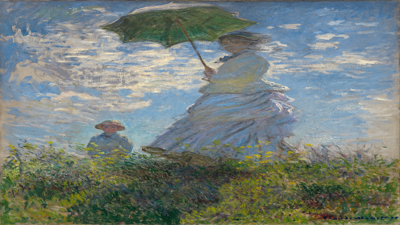

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
target_width = 1920
bounds = input_image.bounds()
scale_x = bc.Int.to_float(target_width) / bounds.width()
target_height = 1080
scale_y = bc.Int.to_float(target_height) / bounds.height()
graph = input_image.transform(
    bc.Transform2.identity().scale(bc.Vector2f.from_components(scale_x, scale_y))
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
